In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json

In [ ]:
#Ler a imagem
imagem = Image.open("imagens/PlacaMercosul.webp")

In [ ]:
print(imagem.mode)
print(imagem.size)

RGB
(900, 506)


In [ ]:
imagem = np.array(imagem)

In [ ]:
print(imagem.shape)

(506, 900, 3)


In [ ]:
#separar os canais

R = imagem[:, :, 0]
G = imagem[:, :, 1]
B = imagem[:, :, 2]

In [ ]:
#height = linhas
#width = colunas

# Módulo A

In [ ]:
#ver depois se essa função precisa mesmo, ou se é desse jeito mesmo, já que a função do módulo B carregarGabor deveria fazer isso
def carregar_kernel(caminho):
  if not caminho.lower().endswith(".json"):
    return np.loadtxt(caminho, dtype=np.float32) # .txt: matriz separada por espaço

  with open(caminho, 'r') as arquivo:
    dados = json.load(arquivo)

    kernel = np.array(
        dados['kernel'],
        dtype=np.float32
    )

  return kernel

In [ ]:
def correlacao_2d(imagem,kernel):

  #tamanho da imagem e do filtro
  h_img, w_img = imagem.shape
  h_k, w_k = kernel.shape

  #descobrir o pivô do filtro
  pad_h = h_k // 2
  pad_w = w_k // 2

  #extensão por 0
  imagem_pad = np.pad(
      imagem,
      ((pad_h, pad_h), (pad_w, pad_w)),
      mode="constant" #substitui por 0
  )

  saida = np.zeros((h_img, w_img), dtype=np.float32) #cria a imagem de saida

  for i in range(h_img):
    for j in range(w_img): #percorre todos os pixels

      vizinhanca = imagem_pad[i:i+h_k,j:j+w_k] #extrai a vizinhança

      saida[i,j] = np.sum(vizinhanca * kernel)

  return saida

# Módulo B

In [ ]:
#carregar json de gabor
def carregar_gabor(caminho):
  with open(caminho, "r") as arquivo:
    params = json.load(arquivo)

  return params

In [ ]:
def gerar_kernel(tamanho, sigma, lambd, gamma, psi, theta_graus):
    meio = tamanho // 2

    y, x = np.mgrid[-meio:meio+1, -meio:meio+1]

    theta = np.deg2rad(theta_graus)

    x_linha = x * np.cos(theta) + y * np.sin(theta)
    y_linha = -x * np.sin(theta) + y * np.cos(theta)

    gaussiana = np.exp(
        -(x_linha**2 + (gamma**2) * y_linha**2) / (2 * sigma**2)
    )

    senoide = np.cos(
        (2 * np.pi * x_linha / lambd) + psi
    )

    gabor = gaussiana * senoide

    return gabor.astype(np.float32)

In [ ]:
# recebe o caminho .json do banco, carrega os parâmetros com carregarGabor e gera uma máscara de Gabor para cada orientação da lista orientacoes_graus.
def gerar_banco_gabor(caminho):
  params = carregar_gabor(caminho)
  # pra cada ângulo theta, chama gerarKernel com os mesmos params do banco e guarda o par (theta, kernel).
  # theta é preservado porque o módulo C precisa dele pra guiar a supressão de não-máximos e manter a borda com exatamente 1 pixel de largura
  return [
      (theta, gerar_kernel(
          params["tamanho_mascara"],
          params["sigma"],
          params["lambda"],
          params["gamma"],
          params["psi"],
          theta,
      ))
      for theta in params["orientacoes_graus"]
  ]
# resultado: lista de pares (ângulo, kernel): o banco completo que o módulo c consome p/ aplicar cada orientação em R, G e B

# Módulo C

In [ ]:
#separar canis rgb
def separar_rgb(imagem_rgb):
    R = imagem_rgb[:, :, 0].astype(np.float32)
    G = imagem_rgb[:, :, 1].astype(np.float32)
    B = imagem_rgb[:, :, 2].astype(np.float32)

    return R, G, B

In [ ]:
# recebe uma img HxWx3 (altura, largura, 3 canais de cor) e aplica correlacao2d separadamente em cada canal (R, G, B) - imagem[:,:,0], imagem [:,:,1], imagem[:,:,2].
def correlacao_rgb(imagem_rgb, kernel):

    canais_filtrados = []

    for c in range(3):
        canal = imagem_rgb[:, :, c]
        canais_filtrados.append(
            correlacao_2d(canal, kernel)
        )

    return np.stack(canais_filtrados, axis=2)
# resultado: cada pixel tem a resposta do kernel aplicada independentemente no seu canal de cor

In [ ]:
def calcular_magnitude_rgb(imagem_filtrada):
    R = imagem_filtrada[:, :, 0]
    G = imagem_filtrada[:, :, 1]
    B = imagem_filtrada[:, :, 2]

    magnitude = np.sqrt(
        R**2 +
        G**2 +
        B**2
    )

    return magnitude

In [ ]:
def atualizar_melhor_resposta(
    magnitude_final,
    orientacao_final,
    magnitude_theta,
    theta
):
    mascara = magnitude_theta > magnitude_final

    magnitude_final[mascara] = magnitude_theta[mascara]
    orientacao_final[mascara] = theta

    return magnitude_final, orientacao_final

In [ ]:
def detector_gabor_rgb(imagem_rgb, params_gabor):

    imagem_rgb = imagem_rgb.astype(np.float32)

    altura, largura, _ = imagem_rgb.shape

    magnitude_final = np.zeros((altura, largura), dtype=np.float32)
    orientacao_final = np.zeros((altura, largura), dtype=np.float32)

    for theta in params_gabor["orientacoes_graus"]:

        kernel = gerar_kernel(
            tamanho=params_gabor["tamanho_mascara"],
            sigma=params_gabor["sigma"],
            lambd=params_gabor["lambda"],
            gamma=params_gabor["gamma"],
            psi=params_gabor["psi"],
            theta_graus=theta
        )

        imagem_filtrada = correlacao_rgb(
            imagem_rgb,
            kernel
        )

        magnitude_theta = calcular_magnitude_rgb(
            imagem_filtrada
        )

        magnitude_final, orientacao_final = atualizar_melhor_resposta(
            magnitude_final,
            orientacao_final,
            magnitude_theta,
            theta
        )

    return magnitude_final, orientacao_final

In [ ]:
# imagem_rgb = np.array(
#     Image.open("sua_imagem.jpg").convert("RGB"),
#     dtype=np.float32
# )

params_gabor = carregar_gabor("filtros/gabor.json")

magnitude_final, orientacao_final = detector_gabor_rgb(
    imagem,
    params_gabor
)

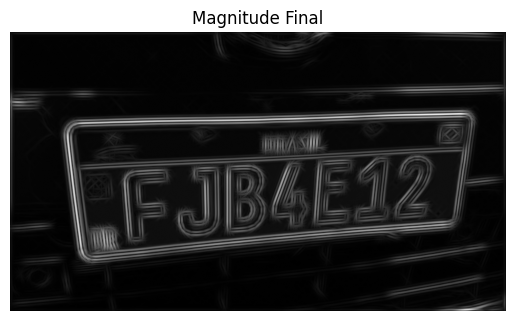

In [ ]:
magnitude_vis = magnitude_final / magnitude_final.max() * 255
magnitude_vis = magnitude_vis.astype(np.uint8)

plt.imshow(magnitude_vis, cmap="gray")
plt.title("Magnitude Final")
plt.axis("off")
plt.show()

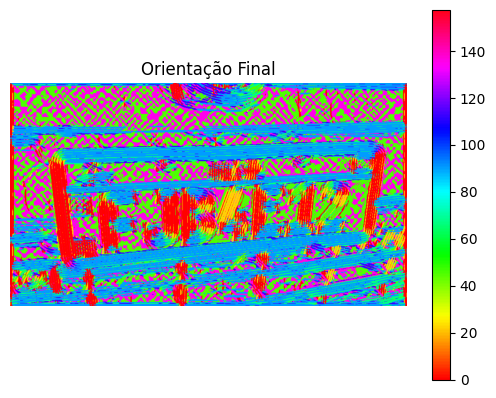

In [ ]:
plt.imshow(orientacao_final, cmap="hsv")
plt.title("Orientação Final")
plt.colorbar()
plt.axis("off")
plt.show()

In [ ]:
def nms(magnitude, orientacao):
    altura, largura = magnitude.shape

    saida = np.zeros((altura, largura), dtype=np.float32)

    for i in range(1, altura - 1):
        for j in range(1, largura - 1):

            angulo = orientacao[i, j]

            # Normalizar para [0, 180)
            angulo = angulo % 180

            atual = magnitude[i, j]

            # 0 graus
            if (0 <= angulo < 22.5) or (157.5 <= angulo < 180):
                vizinho1 = magnitude[i, j - 1]
                vizinho2 = magnitude[i, j + 1]

            # 45 graus
            elif 22.5 <= angulo < 67.5:
                vizinho1 = magnitude[i - 1, j + 1]
                vizinho2 = magnitude[i + 1, j - 1]

            # 90 graus
            elif 67.5 <= angulo < 112.5:
                vizinho1 = magnitude[i - 1, j]
                vizinho2 = magnitude[i + 1, j]

            # 135 graus
            else:
                vizinho1 = magnitude[i - 1, j - 1]
                vizinho2 = magnitude[i + 1, j + 1]

            if atual >= vizinho1 and atual >= vizinho2:
                saida[i, j] = atual
            else:
                saida[i, j] = 0

    return saida

In [ ]:
magnitude_nms = nms(
    magnitude_final,
    orientacao_final
)

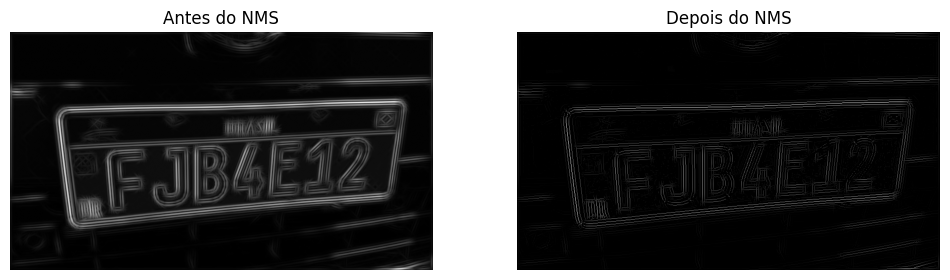

In [ ]:
nms_vis = magnitude_nms / magnitude_nms.max() * 255
nms_vis = nms_vis.astype(np.uint8)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(magnitude_final / magnitude_final.max(), cmap="gray")
plt.title("Antes do NMS")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(nms_vis, cmap="gray")
plt.title("Depois do NMS")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np

def histerese(magnitude_nms, t_low, t_high):
    altura, largura = magnitude_nms.shape

    forte = 255
    fraca = 75

    resultado = np.zeros((altura, largura), dtype=np.uint8)

    fortes_i, fortes_j = np.where(magnitude_nms >= t_high)

    fracas_i, fracas_j = np.where(
        (magnitude_nms >= t_low) & (magnitude_nms < t_high)
    )

    resultado[fortes_i, fortes_j] = forte
    resultado[fracas_i, fracas_j] = fraca

    for i in range(1, altura - 1):
        for j in range(1, largura - 1):

            if resultado[i, j] == fraca:

                vizinhanca = resultado[i-1:i+2, j-1:j+2]

                if np.any(vizinhanca == forte):
                    resultado[i, j] = forte
                else:
                    resultado[i, j] = 0

    resultado[resultado == fraca] = 0

    return resultado

In [ ]:
t_high = magnitude_nms.max() * 0.2
t_low = t_high * 0.5

t_high = magnitude_nms.max() * 0.2
t_low = t_high * 0.5

bordas = histerese(
    magnitude_nms,
    t_low,
    t_high
)

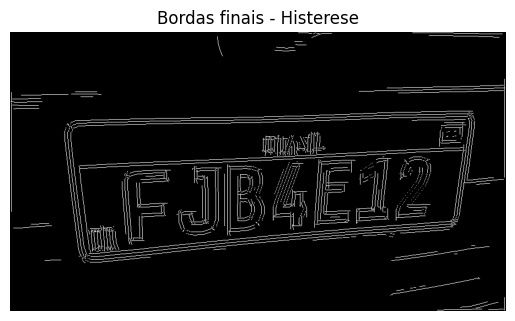

In [ ]:
plt.imshow(bordas, cmap="gray")
plt.title("Bordas finais - Histerese")
plt.axis("off")
plt.show()